# 🏥 Medical X-Ray Classification — Starter Notebook

> 👨‍🏫 **Tác giả:** Nguyễn Quốc Huy (Rinez) - VTI Academy
>
> 📅 **Ngày tạo:** Tháng 4/2026
>
> ⏱️ **Thời gian hoàn thành:** 3 giờ
>
> 📋 **Xem đề bài chi tiết:** `MedicalXray_Practice.md`

---

## 🎯 Mục tiêu: Phân loại X-ray phổi NORMAL vs PNEUMONIA

| Metric | Target |
|--------|--------|
| Accuracy | ≥ 90% |
| Recall | ≥ 95% |
| AUC-ROC | ≥ 0.95 |

## Pipeline:
```
Load Data → EDA → Preprocessing → CNN Baseline → VGG16 FE → ResNet50 FT → Class Weight → Evaluate
```

---
## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers



from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU: []


---
## Task 1: Load & Khám Phá Dữ Liệu (EDA) 📊

### 1.1. Download & Load dataset

> 📥 Download từ Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
>
> Upload lên Google Drive hoặc dùng Kaggle API

In [2]:
import kagglehub

# Tải phiên bản mới nhất của bộ dữ liệu
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dữ liệu đã được tải về tại:", path)

Dữ liệu đã được tải về tại: C:\Users\Admin\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [3]:
import kagglehub
import pathlib
import os

# Download dataset
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset path:", path)
print("Folders:", os.listdir(path))

# Đường dẫn dataset
DATA_DIR = pathlib.Path(path) / "chest_xray"

train_dir = DATA_DIR / 'train'
val_dir = DATA_DIR / 'val'
test_dir = DATA_DIR / 'test'

# Đếm ảnh
for split_name, split_dir in [
    ('Train', train_dir),
    ('Val', val_dir),
    ('Test', test_dir)
]:
    n_normal = len(list(split_dir.glob('NORMAL/*')))
    n_pneumonia = len(list(split_dir.glob('PNEUMONIA/*')))

    print(
        f"{split_name:6s}: "
        f"NORMAL={n_normal:5d} | "
        f"PNEUMONIA={n_pneumonia:5d} | "
        f"Total={n_normal+n_pneumonia}"
    )

Dataset path: C:\Users\Admin\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Folders: ['chest_xray']
Train : NORMAL= 1341 | PNEUMONIA= 3875 | Total=5216
Val   : NORMAL=    8 | PNEUMONIA=    8 | Total=16
Test  : NORMAL=  234 | PNEUMONIA=  390 | Total=624


In [4]:
# Load datasets

# train_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dir,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     seed=RANDOM_STATE,
#     label_mode='binary'
# )

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=RANDOM_STATE,
    label_mode='binary'
)

# Val set quá nhỏ (16 ảnh) → gộp val vào train, tách lại từ train
# Hoặc tạo val mới từ train
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print(f"\nClasses: {train_ds.class_names}")

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.

Classes: ['NORMAL', 'PNEUMONIA']


In [5]:
# Tạo validation set từ train (vì val gốc quá nhỏ)
# TODO: Chia 15% train thành validation
train_size = int(0.85 * tf.data.experimental.cardinality(train_ds).numpy())
val_ds = train_ds.skip(train_size)
train_ds = train_ds.take(train_size)

print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Train batches: 138
Val batches: 25
Test batches: 20


### 1.2. Visualize mẫu ảnh

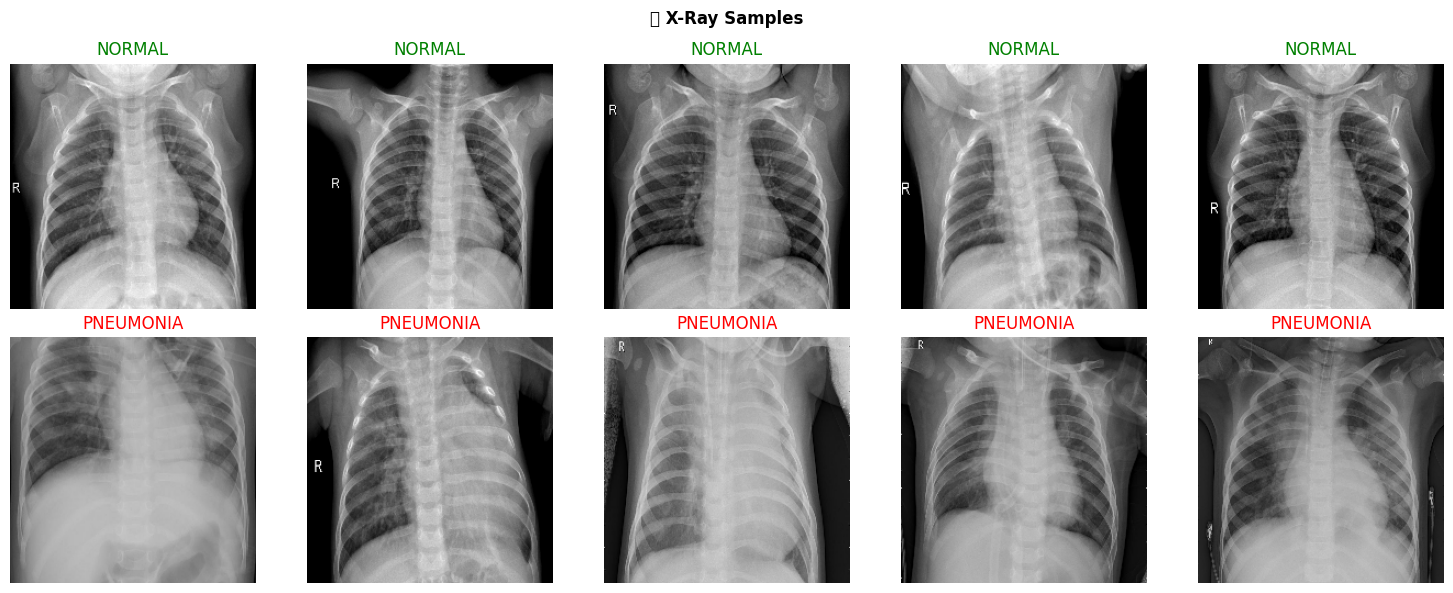

In [6]:
# TODO: Hiển thị 5 ảnh NORMAL + 5 ảnh PNEUMONIA
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Lấy 1 batch
for images, labels in train_ds.take(1):
    # Tách normal và pneumonia
    normal_mask = labels.numpy().flatten() == 0
    pneumonia_mask = labels.numpy().flatten() == 1
    
    normal_imgs = images[normal_mask]
    pneumonia_imgs = images[pneumonia_mask]
    
    for i in range(min(5, len(normal_imgs))):
        axes[0, i].imshow(normal_imgs[i].numpy().astype('uint8'), cmap='gray')
        axes[0, i].set_title('NORMAL', color='green')
        axes[0, i].axis('off')
    
    for i in range(min(5, len(pneumonia_imgs))):
        axes[1, i].imshow(pneumonia_imgs[i].numpy().astype('uint8'), cmap='gray')
        axes[1, i].set_title('PNEUMONIA', color='red')
        axes[1, i].axis('off')

plt.suptitle('🏥 X-Ray Samples', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3. Class Imbalance Analysis

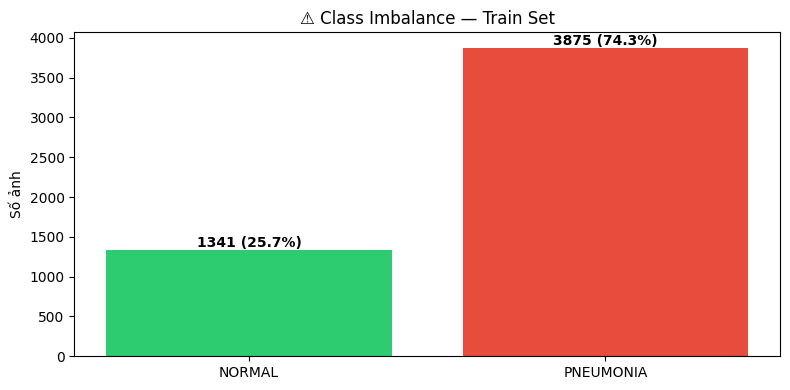

Ratio: PNEUMONIA/NORMAL = 2.89x


In [7]:
# TODO: Vẽ biểu đồ phân bố class
n_normal = len(list(train_dir.glob('NORMAL/*')))
n_pneumonia = len(list(train_dir.glob('PNEUMONIA/*')))
total = n_normal + n_pneumonia

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['NORMAL', 'PNEUMONIA'], [n_normal, n_pneumonia],
              color=['#2ecc71', '#e74c3c'])
for bar, count in zip(bars, [n_normal, n_pneumonia]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count} ({count/total*100:.1f}%)', ha='center', fontweight='bold')

ax.set_title('⚠️ Class Imbalance — Train Set')
ax.set_ylabel('Số ảnh')
plt.tight_layout()
plt.show()

print(f"Ratio: PNEUMONIA/NORMAL = {n_pneumonia/n_normal:.2f}x")

---
## Task 1.5: Preprocessing Pipeline 🧹

In [8]:
# Data Augmentation (cẩn thận với medical images!)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),       # ✅ X-ray đối xứng
    layers.RandomRotation(0.1),            # ✅ ±10° nhỏ
    layers.RandomZoom(0.1),                # ✅ ±10% nhỏ
    layers.RandomContrast(0.1),            # ✅ contrast nhẹ
], name='augmentation')

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("✅ Pipeline ready!")

✅ Pipeline ready!


---
## Task 2: CNN Baseline 🏗️

```
Rescale → Augment → Conv(32)→BN→Pool → Conv(64)→BN→Pool → Conv(128)→BN→Pool → Conv(256)→BN→Pool → GAP → Dense(256) → Dropout → Dense(1, sigmoid)
```

In [9]:
# TODO: Xây dựng CNN Baseline
model_baseline = models.Sequential([
    layers.Rescaling(1./255, input_shape=(*IMG_SIZE, 3)),
    data_augmentation,
    
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='CNN_Baseline')

model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history_baseline = model_baseline.fit(
    train_ds, validation_data=val_ds,
    epochs=30, callbacks=my_callbacks, verbose=1
)

baseline_loss, baseline_acc = model_baseline.evaluate(test_ds, verbose=0)
print(f"\n🎯 CNN Baseline — Test Accuracy: {baseline_acc:.4f}")

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.8716 - loss: 0.2819 - val_accuracy: 0.7563 - val_loss: 3.2634 - learning_rate: 0.0010
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.9031 - loss: 0.2322 - val_accuracy: 0.7563 - val_loss: 2.4167 - learning_rate: 0.0010
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9164 - loss: 0.2093 - val_accuracy: 0.7725 - val_loss: 0.5814 - learning_rate: 0.0010
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.9321 - loss: 0.1781 - val_accuracy: 0.7563 - val_loss: 3.4924 - learning_rate: 0.0010
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9353 - loss: 0.1669
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.9346 - loss: 0.1666 - val_accuracy: 0.7563 - val_loss: 9.5129 - learning_rate: 0.0010
Epoch 6/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 396s 3s/step - accuracy: 0.9434 - loss: 0.148

---
## Task 3: VGG16 Feature Extraction 🧊

> Freeze toàn bộ VGG16 backbone → chỉ train classifier mới

In [ ]:
# TODO: Load VGG16 pretrained
vgg_base = tf.keras.applications.VGG16(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
vgg_base.trainable = False  # FREEZE!

model_vgg = models.Sequential([
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input, input_shape=(*IMG_SIZE, 3)),
    data_augmentation,
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='VGG16_FeatureExtraction')

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params: {model_vgg.count_params() - vgg_base.count_params():,}")
print(f"Frozen params:    {vgg_base.count_params():,}")


Trainable params: 131,585
Frozen params:    14,714,688


In [ ]:
history_vgg = model_vgg.fit(
    train_ds, validation_data=val_ds,
    epochs=20, callbacks=my_callbacks, verbose=1
)

vgg_loss, vgg_acc = model_vgg.evaluate(test_ds, verbose=0)
print(f"\n🎯 VGG16 Feature Extraction — Test Accuracy: {vgg_acc:.4f}")

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 751s 5s/step - accuracy: 0.8854 - loss: 0.3159 - val_accuracy: 0.8687 - val_loss: 0.4749 - learning_rate: 0.0010
Epoch 2/20
 61/138 ━━━━━━━━━━━━━━━━━━━━ 5:23 4s/step - accuracy: 0.9257 - loss: 0.1716

---
## Task 4: ResNet50 Fine-tuning 🔓

> Feature Extraction trước → Unfreeze top layers → Fine-tune với LR nhỏ

In [ ]:
# TODO: Load ResNet50
resnet_base = tf.keras.applications.ResNet50(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
resnet_base.trainable = False

model_resnet = models.Sequential([
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input, input_shape=(*IMG_SIZE, 3)),
    data_augmentation,
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50')

model_resnet.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("📦 Phase 1: Feature Extraction")
history_resnet_fe = model_resnet.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=my_callbacks, verbose=1
)

In [ ]:
# Phase 2: Fine-tuning
resnet_base.trainable = True

# Freeze tất cả trừ 30 layers cuối
fine_tune_at = len(resnet_base.layers) - 30
for layer in resnet_base.layers[:fine_tune_at]:
    layer.trainable = False

model_resnet.compile(
    optimizer=optimizers.Adam(1e-5),   # LR rất nhỏ!
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔓 Phase 2: Fine-tuning")
history_resnet_ft = model_resnet.fit(
    train_ds, validation_data=val_ds,
    epochs=15, callbacks=my_callbacks, verbose=1
)

resnet_loss, resnet_acc = model_resnet.evaluate(test_ds, verbose=0)
print(f"\n🎯 ResNet50 Fine-tuning — Test Accuracy: {resnet_acc:.4f}")

---
## Task 5: Class Imbalance ⚖️

In [ ]:
# TODO: Tính class weights
n_normal = len(list(train_dir.glob('NORMAL/*')))
n_pneumonia = len(list(train_dir.glob('PNEUMONIA/*')))
total = n_normal + n_pneumonia

class_weight = {
    0: total / (2 * n_normal),
    1: total / (2 * n_pneumonia)
}

print(f"NORMAL weight:    {class_weight[0]:.4f}")
print(f"PNEUMONIA weight: {class_weight[1]:.4f}")
print(f"\n→ NORMAL (thiểu số) có weight CAO hơn → model chú ý hơn")

In [ ]:
# TODO: Train lại best model với class_weight
# (Ví dụ: train lại ResNet50 từ feature extraction)
resnet_base_cw = tf.keras.applications.ResNet50(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet'
)
resnet_base_cw.trainable = False

model_cw = models.Sequential([
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input, input_shape=(*IMG_SIZE, 3)),
    data_augmentation,
    resnet_base_cw,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50_ClassWeight')

model_cw.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cw = model_cw.fit(
    train_ds, validation_data=val_ds,
    epochs=20, callbacks=my_callbacks,
    class_weight=class_weight,   # ← ĐÂY!
    verbose=1
)

cw_loss, cw_acc = model_cw.evaluate(test_ds, verbose=0)
print(f"\n🎯 ResNet50 + Class Weight — Test Accuracy: {cw_acc:.4f}")

---
## Task 6: Đánh Giá Tổng Hợp 📊

In [ ]:
import pandas as pd

# Collect predictions
all_models = {
    'CNN Baseline': model_baseline,
    'VGG16 FE': model_vgg,
    'ResNet50 FT': model_resnet,
    'ResNet50 + CW': model_cw
}

# Get true labels from test_ds
y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten()

rows = []
for name, model in all_models.items():
    y_prob = model.predict(test_ds, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = np.mean(y_pred == y_true)
    auc = roc_auc_score(y_true, y_prob)
    
    # Recall & Precision for PNEUMONIA (class 1)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    rows.append({
        'Model': name,
        'Accuracy': f'{acc:.4f}',
        'Recall': f'{recall:.4f}',
        'Precision': f'{precision:.4f}',
        'AUC': f'{auc:.4f}',
        'Params': f'{model.count_params():,}'
    })

results = pd.DataFrame(rows)
print("=" * 80)
print("🏆 BẢNG SO SÁNH TẤT CẢ MODELS")
print("=" * 80)
print(results.to_string(index=False))

In [ ]:
# === ROC CURVE OVERLAY ===
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in all_models.items():
    y_prob = model.predict(test_ds, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Medical X-Ray Classification')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# === CONFUSION MATRIX - Best Model ===
# TODO: Chọn best model (thường là ResNet50 FT hoặc ResNet50+CW)
best_model = model_resnet  # Sửa nếu cần
best_name = 'ResNet50 FT'

y_prob_best = best_model.predict(test_ds, verbose=0).flatten()
y_pred_best = (y_prob_best >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_best, target_names=CLASS_NAMES))

In [ ]:
# === PHÂN TÍCH SAI: Hiển thị ảnh bị phân loại sai ===
wrong_indices = np.where(y_pred_best != y_true)[0]
print(f"Tổng ảnh sai: {len(wrong_indices)} / {len(y_true)}")

# Lấy ảnh từ test_ds
all_images = np.concatenate([x.numpy() for x, _ in test_ds])

n_show = min(10, len(wrong_indices))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat[:n_show]):
    idx = wrong_indices[i]
    ax.imshow(all_images[idx].astype('uint8'), cmap='gray')
    true_label = CLASS_NAMES[int(y_true[idx])]
    pred_label = CLASS_NAMES[int(y_pred_best[idx])]
    conf = y_prob_best[idx] if y_pred_best[idx] == 1 else 1 - y_prob_best[idx]
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.1%})', 
                fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('❌ Các ca phân loại SAI', fontweight='bold')
plt.tight_layout()
plt.show()

---
## (Bonus) Grad-CAM Visualization 🔍

> Visualize vùng ảnh model "nhìn vào" khi chẩn đoán → giải thích cho bác sĩ

In [ ]:
# TODO (Bonus): Implement Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Generate Grad-CAM heatmap"""
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Sử dụng:
# heatmap = make_gradcam_heatmap(img_array, model, 'last_conv_layer_name')
# plt.imshow(heatmap, cmap='jet', alpha=0.5)
print("💡 Implement Grad-CAM visualization trên ảnh PNEUMONIA")

---
## 📝 Kết Luận

Viết kết luận của bạn:

1. **Model tốt nhất**: ...
2. **Tại sao**: ...
3. **Class Weight**: có cải thiện Recall không? ...
4. **Recommendations cho VTI Hospital**: ...
5. **Hạn chế & hướng phát triển**: ...

---

## 📤 Nộp bài

| Nộp | Format |
|-----|--------|
| Notebook (.ipynb) | Đã chạy xong, có output |
| Bảng so sánh | Screenshot hoặc copy text |
| Kết luận | 5-10 câu |